# Facebook Social Circles Network — Spectral Clustering Benchmark

**COMP702 Dissertation · Milestone 4**

The last dataset in the series (after synthetic, US Airports, and Yeast PPI): the
same five algorithms, conventions, and three-embedding evaluation, on the Stanford
SNAP **ego-Facebook** friendship network — again with no ground truth.

| Algorithm | Reference |
|---|---|
| K-Means (baseline) | Lloyd (1957) |
| Unnormalised Spectral Clustering | von Luxburg (2007) |
| Normalised SC — Shi & Malik | Shi & Malik (2000) |
| Normalised SC — Ng, Jordan & Weiss | Ng, Jordan & Weiss (2001) |
| Self-Tuning SC — Zelnik-Manor & Perona | Zelnik-Manor & Perona (2004) |

As on the other networks, the K-Means baseline and Self-Tuning SC operate on the
unnormalised-Laplacian node embedding; the three graph-native spectral methods
operate on the adjacency.

## Prediction (stated before running anything)

From the pre-analysis degree diagnostic, Facebook has the **lowest degree-1
proportion of the three real datasets — 1.9%**, versus **Airports 9.6%** and
**Yeast 49.5%**. Degree-1 leaf population was the dominant driver of
unnormalised-Laplacian degeneracy on Airports (one leaf isolated) and Yeast
(fragment splits, and even Shi-Malik collapsing). So the prediction is:

> If the degree-1 leaf population is the dominant driver of degeneracy, then on
> Facebook **Shi-Malik's modularity should land at or above Airports' 0.136**, and
> **Ng-Jordan-Weiss should remain the most consistent performer** (continuing
> +0.223 on Airports and +0.242 on Yeast).

**Open question / alternative hypothesis.** Facebook has a much higher maximum
degree (**1,045**) and larger scale (**4,039 nodes**) than the others — untested
variables. If the prediction does *not* hold, that would point to hub-dominance or
scale as an alternative mechanism worth investigating separately, rather than the
degree-1 leaf story. Section 9 revisits this explicitly.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_repo = _here if (_here / "scripts").exists() else _here.parent
sys.path.insert(0, str(_repo))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import SEED
from scripts.network_datasets import load_facebook
from scripts.selection import select_spectral_k
from scripts.spectral import (kmeans_baseline, unnormalised_spectral, spectral_shi_malik,
                              spectral_ng_jordan_weiss, self_tuning_spectral)
from scripts.network_eval import (build_embeddings, evaluate_multi_embedding,
                                  ranking_consistency, consistency_verdict,
                                  format_comparison_table, EMBEDDINGS)

np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110
print(f"Global seed = {SEED}")

Global seed = 42


## 1. Setup and data loading

Each **node** is a Facebook user; each undirected **edge** is a friendship
connection (unweighted). The graph is the SNAP `facebook_combined` ego-network,
loaded via `scripts.network_datasets.load_facebook`.

In [2]:
A, nodes, G = load_facebook()
import networkx as nx
n_nodes, n_edges = A.shape[0], int(A.nnz // 2)
print(f"Facebook Social Circles: {n_nodes} nodes, {n_edges} edges")
print(f"Single connected component? {nx.is_connected(G)}")

Facebook Social Circles: 4039 nodes, 88234 edges
Single connected component? True


## 2. Graph structure overview

The pre-analysis diagnostic already compared all three real degree distributions
side by side; the key figures are **1.9% degree-1 nodes**, median degree 25, mean
43.7, and a heavy tail up to degree 1,045. Facebook is the **least leaf-heavy** of
the three (Airports 9.6%, Yeast 49.5%) but the **most hub-heavy** (highest maximum
degree). The single-panel view below is included for completeness.

Degree: min=1, median=25, mean=43.7, max=1045
Degree-1 nodes: 75 (1.9% of the network)  [Airports ~9.6%, Yeast ~49.5%]


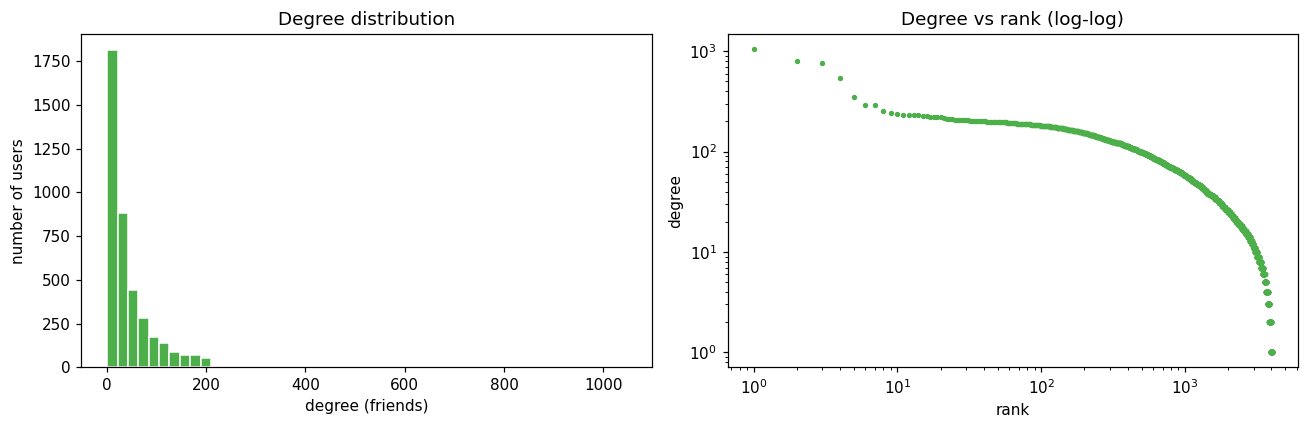

In [3]:
deg = np.array([d for _, d in G.degree()])
order = np.argsort(-deg)
n_deg1 = int((deg == 1).sum())
print(f"Degree: min={deg.min()}, median={np.median(deg):.0f}, mean={deg.mean():.1f}, "
      f"max={deg.max()}")
print(f"Degree-1 nodes: {n_deg1} ({100*n_deg1/n_nodes:.1f}% of the network)  "
      f"[Airports ~9.6%, Yeast ~49.5%]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deg, bins=50, color="#4daf4a", edgecolor="white")
axes[0].set_title("Degree distribution"); axes[0].set_xlabel("degree (friends)")
axes[0].set_ylabel("number of users")
axes[1].loglog(np.arange(1, n_nodes + 1), deg[order], "o", ms=2.5, color="#4daf4a")
axes[1].set_title("Degree vs rank (log-log)")
axes[1].set_xlabel("rank"); axes[1].set_ylabel("degree")
plt.tight_layout(); plt.show()

## 3. Choosing *k*

Same two-step spectral k-selection (candidate shortlist + Silhouette
disambiguation); the stored benchmark previously found *k* = 7. Facebook's five
4039-node eigendecompositions are the one expensive step in this notebook, so they
are **cached** to `results/facebook_cache.{npz,json}`: the cell below loads that
cache if present (fast) and otherwise recomputes it (~90 s) and saves it. The
cache stores the k-selection diagnostics, the five algorithms' labels, and the
force-directed layout used in Section 8 — everything is fully reproducible from
the fixed seed.

Loaded cached Facebook computation (labels, layout, k-selection).
candidates = [7, 8, 4]  ->  two-step k = 7 (Silhouette disambiguation)
Silhouette per candidate: {7: 0.751, 8: 0.649, 4: 0.458}


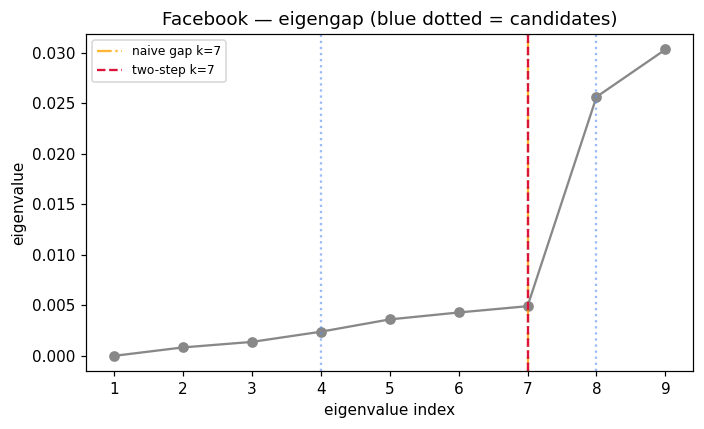

In [4]:
cache_npz = _repo / "results" / "facebook_cache.npz"
cache_json = _repo / "results" / "facebook_cache.json"

if cache_npz.exists() and cache_json.exists():
    _d = np.load(cache_npz); _cj = json.load(open(cache_json))
    algo_names = _cj["algos"]
    labels = {a: _d[f"lab_{i}"] for i, a in enumerate(algo_names)}
    pos_array = _d["pos"]
    k = int(_cj["k"]); candidates = _cj["candidates"]; naive_k = int(_cj["naive"])
    cand_scores = {int(kk): v for kk, v in _cj["scores"].items()}
    eigs = np.array(_cj["eigs"])
    print("Loaded cached Facebook computation (labels, layout, k-selection).")
else:
    print("No cache found — recomputing (~90 s)...")
    emb, _ = build_embeddings(A, n_components=10); Xe = emb["unnorm"]; Ad = A.toarray()
    sel = select_spectral_k(Ad, Xe, reference_fn=lambda kk: spectral_ng_jordan_weiss(Ad, kk),
                            ground_truth=None, top_n=3, k_min=2, k_max=8)
    k = sel["best_k"]; candidates = sel["candidates"]; naive_k = sel["naive_suggested_k"]
    cand_scores = sel["scores"]; eigs = np.array(sel["eigenvalues"])
    labels = {"K-Means (embedding)": np.asarray(kmeans_baseline(Xe, k)),
              "Unnormalised SC": np.asarray(unnormalised_spectral(Ad, k)),
              "Shi-Malik SC": np.asarray(spectral_shi_malik(Ad, k)),
              "Ng-Jordan-Weiss SC": np.asarray(spectral_ng_jordan_weiss(Ad, k)),
              "Self-Tuning SC (embedding)": np.asarray(self_tuning_spectral(Xe, k))}
    pos_array = np.array([nx.spring_layout(G, seed=SEED, iterations=50)[nodes[i]]
                          for i in range(len(nodes))])
    np.savez(cache_npz, pos=pos_array, **{f"lab_{i}": l for i, l in enumerate(labels.values())})
    json.dump({"algos": list(labels.keys()), "k": int(k),
               "candidates": [int(c) for c in candidates], "naive": int(naive_k),
               "scores": {str(kk): float(v) for kk, v in cand_scores.items()},
               "eigs": [float(x) for x in eigs]}, open(cache_json, "w"))

print(f"candidates = {candidates}  ->  two-step k = {k} (Silhouette disambiguation)")
print(f"Silhouette per candidate: { {kk: round(v, 3) for kk, v in cand_scores.items()} }")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(eigs) + 1), eigs, "o-", color="#888")
for c in candidates:
    ax.axvline(c, color="#5b8def", ls=":", alpha=0.6)
ax.axvline(naive_k, color="orange", ls="-.", alpha=0.8, label=f"naive gap k={naive_k}")
ax.axvline(k, color="crimson", ls="--", label=f"two-step k={k}")
ax.set_title("Facebook — eigengap (blue dotted = candidates)")
ax.set_xlabel("eigenvalue index"); ax.set_ylabel("eigenvalue"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Run all five algorithms

Same fixed seed and `n_init=10` convention. (Labels loaded from the cache above;
the recompute branch runs them live.)

In [5]:
for name, lab in labels.items():
    sizes = sorted(np.bincount(lab).tolist(), reverse=True)
    print(f"{name:28s} cluster sizes = {sizes}")

K-Means (embedding)          cluster sizes = [1368, 786, 753, 548, 341, 184, 59]
Unnormalised SC              cluster sizes = [1348, 786, 752, 548, 341, 205, 59]
Shi-Malik SC                 cluster sizes = [1348, 786, 752, 548, 341, 205, 59]
Ng-Jordan-Weiss SC           cluster sizes = [1342, 785, 752, 546, 345, 208, 61]
Self-Tuning SC (embedding)   cluster sizes = [3963, 25, 17, 11, 10, 8, 5]


## 4b. Degenerate split check

As on Airports and Yeast, we check the unnormalised methods (and Self-Tuning) for
degenerate or near-degenerate splits before trusting anything.

In [6]:
deg = np.array([d for _, d in G.degree()])
for name in ["K-Means (embedding)", "Unnormalised SC", "Self-Tuning SC (embedding)"]:
    sizes = sorted(np.bincount(labels[name]).tolist(), reverse=True)
    frac = max(sizes) / sum(sizes)
    verdict = ("DEGENERATE (one dominant cluster)" if frac > 0.9
               else "balanced / non-degenerate")
    print(f"{name:28s} largest cluster = {100*frac:.0f}% of nodes  ->  {verdict}")

print("\nSelf-Tuning is the only degenerate one — its non-giant fragments:")
st = labels["Self-Tuning SC (embedding)"]
for c in np.unique(st):
    idx = np.where(st == c)[0]
    if len(idx) < 200:
        ds = deg[idx]
        print(f"  fragment of {len(idx):3d} nodes: degree {ds.min()}-{ds.max()} (mean {ds.mean():.1f})")
print("Note: these fragments span a wide degree range (not degree-1 leaves), so "
      "Self-Tuning's failure here is NOT the degree-1 mechanism seen on Airports/Yeast.")

K-Means (embedding)          largest cluster = 34% of nodes  ->  balanced / non-degenerate
Unnormalised SC              largest cluster = 33% of nodes  ->  balanced / non-degenerate
Self-Tuning SC (embedding)   largest cluster = 98% of nodes  ->  DEGENERATE (one dominant cluster)

Self-Tuning is the only degenerate one — its non-giant fragments:
  fragment of  10 nodes: degree 3-8 (mean 5.5)
  fragment of  11 nodes: degree 1-2 (mean 1.2)
  fragment of  17 nodes: degree 7-19 (mean 13.9)
  fragment of  25 nodes: degree 12-25 (mean 21.9)
  fragment of   5 nodes: degree 12-16 (mean 13.2)
  fragment of   8 nodes: degree 14-15 (mean 14.8)
Note: these fragments span a wide degree range (not degree-1 leaves), so Self-Tuning's failure here is NOT the degree-1 mechanism seen on Airports/Yeast.


### What the check shows

Unlike Airports ($[726, 1]$) and Yeast (giant + fragments), **K-Means and
Unnormalised SC do *not* degenerate on Facebook** — both return balanced
seven-way partitions where the largest cluster is only ~34% of nodes. This is the
first real network where the unnormalised methods succeed, and it is exactly what
the low 1.9% degree-1 fraction predicts.

The **only** degenerate method is **Self-Tuning SC** ($[3963, 25, 17, \dots]$, one
giant cluster + small fragments). Crucially, its fragments span a wide range of
degrees rather than being degree-1 leaves, so this is *not* the degree-imbalance
mechanism — it is Self-Tuning's own local-scaling affinity failing on a graph
embedding, the same intrinsic weakness seen on every real network.

## 5. Evaluation under three embeddings

Silhouette and Davies-Bouldin under the three neutral embeddings, loaded from
`results/network_eval_facebook.json` (recomputed only if the derived *k* differs
from the stored *k* = 7).

In [7]:
res_path = _repo / "results" / "network_eval_facebook.json"
if k == 7 and res_path.exists():
    stored = json.load(open(res_path))
    print(f"Loaded precomputed results from {res_path.name} (k = {stored['k']}, "
          f"shortest-path timing {stored.get('shortest_path_seconds')} s).")
    df = pd.DataFrame(stored["table"])
else:
    print(f"Derived k = {k} differs from stored; recomputing.")
    df, _t = evaluate_multi_embedding(A, labels, n_components=10)

print("\nSilhouette Score by embedding (higher is better):")
print(format_comparison_table(df, "silhouette").to_string(index=False))
print("\nDavies-Bouldin Index by embedding (lower is better):")
print(format_comparison_table(df, "davies_bouldin").to_string(index=False))

for metric in ("silhouette", "davies_bouldin"):
    cons = ranking_consistency(df, metric=metric)
    print("\n" + consistency_verdict(cons, "facebook"))
    print(f"  Spearman(rank) between embeddings: "
          f"{ {kk: round(v, 2) for kk, v in cons['spearman'].items()} }")

Loaded precomputed results from network_eval_facebook.json (k = 7, shortest-path timing 4.793 s).

Silhouette Score by embedding (higher is better):
                 algorithm  silhouette_unnorm  silhouette_sym  silhouette_shortest_path
       K-Means (embedding)             0.7432          0.3605                    0.7001
           Unnormalised SC             0.7514          0.3639                    0.7112
              Shi-Malik SC             0.7514          0.3639                    0.7112
        Ng-Jordan-Weiss SC             0.7505          0.3641                    0.7111
Self-Tuning SC (embedding)             0.0118         -0.3694                   -0.1107

Davies-Bouldin Index by embedding (lower is better):
                 algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
       K-Means (embedding)                 0.5258              1.1632                        0.4927
           Unnormalised SC                 0.6536              1.1639

## 6. Modularity

Facebook edges are **unweighted friendship connections**, so — as with Yeast PPI
(and *unlike* Airports, whose flight-count weights called for weighted
modularity) — we use **unweighted modularity** here. We flag this choice
explicitly because the three datasets have different edge semantics.

In [8]:
from networkx.algorithms.community import modularity
idxmap = {nd: i for i, nd in enumerate(nodes)}
print("Unweighted modularity Q (higher = denser communities; ~0 = no better than random):")
Q_facebook = {}
for name, lab in labels.items():
    comms = {}
    for nd in G.nodes():
        comms.setdefault(int(lab[idxmap[nd]]), set()).add(nd)
    Q_facebook[name] = modularity(G, list(comms.values()), weight=None)
for name, q in sorted(Q_facebook.items(), key=lambda t: -t[1]):
    sizes = sorted(np.bincount(labels[name]).tolist(), reverse=True)
    print(f"  {name:28s} Q = {q:+.3f}   sizes = {sizes}")

Unweighted modularity Q (higher = denser communities; ~0 = no better than random):


  Ng-Jordan-Weiss SC           Q = +0.708   sizes = [1342, 785, 752, 546, 345, 208, 61]
  Unnormalised SC              Q = +0.708   sizes = [1348, 786, 752, 548, 341, 205, 59]
  Shi-Malik SC                 Q = +0.708   sizes = [1348, 786, 752, 548, 341, 205, 59]
  K-Means (embedding)          Q = +0.707   sizes = [1368, 786, 753, 548, 341, 184, 59]
  Self-Tuning SC (embedding)   Q = +0.010   sizes = [3963, 25, 17, 11, 10, 8, 5]


**Result.** Four of the five methods — K-Means, Unnormalised SC, Shi-Malik,
and Ng-Jordan-Weiss — all land at **Q ≈ 0.71**, an unusually strong and
essentially identical community structure. Only **Self-Tuning** fails (Q ≈ 0.01).
This is a sharp contrast with Airports and Yeast, where the unnormalised methods
degenerated to Q ≈ 0: on this leaf-free, clearly-modular network, degree
normalisation is no longer decisive — even the plain unnormalised Laplacian
recovers the same seven communities.

## 7. Consistency and circularity

In [9]:
sil = df.set_index("algorithm")
km = sil.loc["K-Means (embedding)"]
print("K-Means Silhouette across embeddings:")
print(f"   unnormalised = {km['silhouette_unnorm']:+.3f}   "
      f"symmetric = {km['silhouette_sym']:+.3f}   "
      f"shortest-path = {km['silhouette_shortest_path']:+.3f}")
csil = ranking_consistency(df, "silhouette")
print(f"\nSilhouette winner per embedding: {csil['winners']}")
print(f"Silhouette rank correlation unnorm~sym = {csil['spearman']['unnorm~sym']:+.2f}")

K-Means Silhouette across embeddings:
   unnormalised = +0.743   symmetric = +0.360   shortest-path = +0.700

Silhouette winner per embedding: {'unnorm': 'Unnormalised SC', 'sym': 'Ng-Jordan-Weiss SC', 'shortest_path': 'Unnormalised SC'}
Silhouette rank correlation unnorm~sym = +0.60


### Reading

Facebook sits **between** Airports and Yeast on embedding stability: the Silhouette
ranking is *broadly* consistent (unnorm~shortest-path agree perfectly; unnorm~sym
correlate moderately), not the near-perfect agreement of Yeast nor the
anti-correlation of Airports. Fit-space circularity is present but mild — K-Means
scores higher under its own unnormalised embedding than under the symmetric one —
but here that is **not** masking a degenerate split: K-Means genuinely recovers the
seven communities (Q ≈ 0.71), so the drop reflects the embedding's geometry rather
than a trivial clustering being flattered. As always, no single embedding's
"winner" should be over-read; the robust signal is that the four Laplacian-based
methods agree.

## 8. Visualisation

Force-directed layout grid for all five algorithms, consistent with the Airports
and Yeast notebooks. At 4,039 nodes and 88,234 edges, the `spring_layout` is
**precomputed once and cached** (Section 3), and the edges are **sub-sampled**
(15,000 of 88,234) and drawn thin/transparent so the community structure is
visible rather than a solid mass.

Force-directed layout of 4039 users; drawing 15000 of 88234 friendship edges.


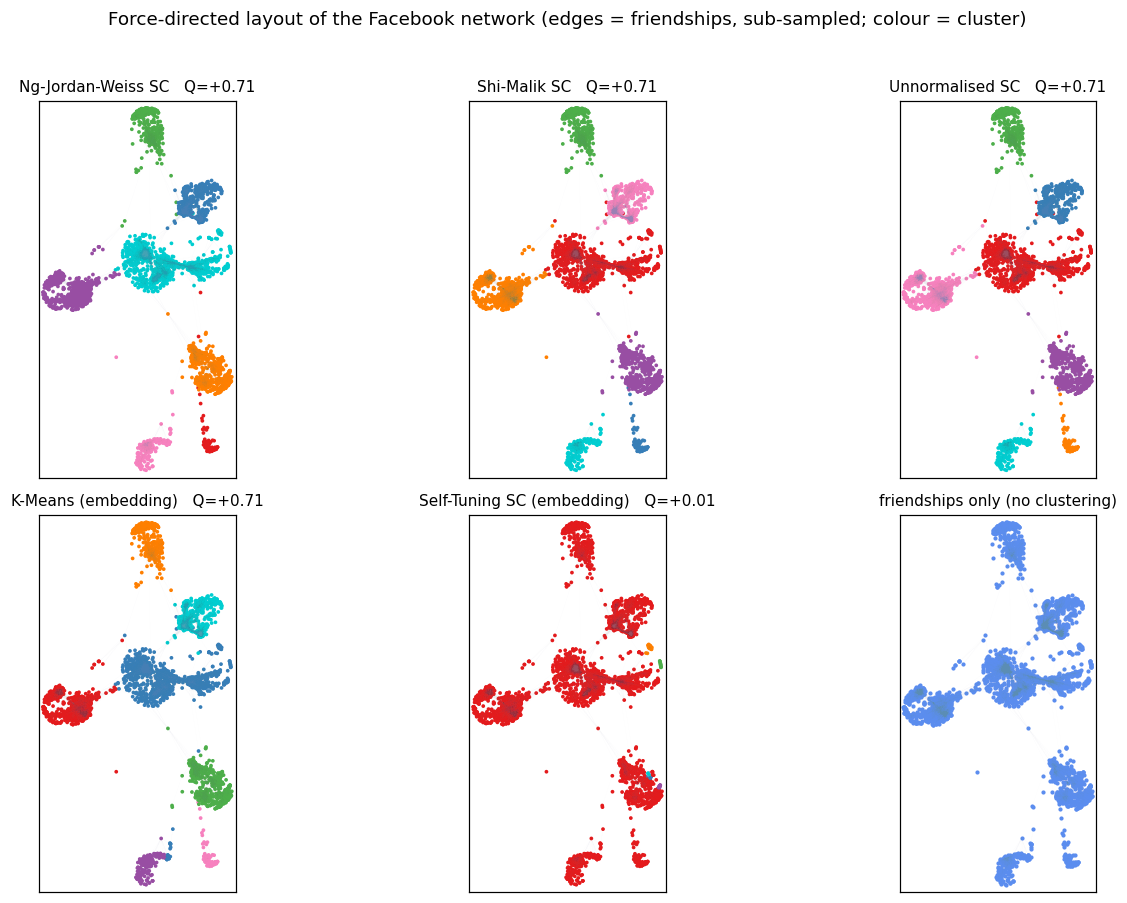

In [10]:
from matplotlib.collections import LineCollection

PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
           "#00ced1", "#f781bf", "#a65628"]
cc = lambda lab: [PALETTE[int(c) % len(PALETTE)] for c in lab]

idx = {nd: i for i, nd in enumerate(nodes)}
edge_idx = np.array([(idx[u], idx[v]) for u, v in G.edges()])
rng = np.random.default_rng(SEED)
samp = rng.choice(len(edge_idx), size=min(15000, len(edge_idx)), replace=False)
segs = pos_array[edge_idx[samp]]
print(f"Force-directed layout of {len(nodes)} users; "
      f"drawing {len(samp)} of {len(edge_idx)} friendship edges.")

panels = ["Ng-Jordan-Weiss SC", "Shi-Malik SC", "Unnormalised SC",
          "K-Means (embedding)", "Self-Tuning SC (embedding)", None]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
for ax, algo in zip(axes.ravel(), panels):
    ax.add_collection(LineCollection(segs, colors="#9aa2b4", linewidths=0.12, alpha=0.05))
    if algo is None:
        ax.scatter(pos_array[:, 0], pos_array[:, 1], s=3, c="#5b8def")
        ax.set_title("friendships only (no clustering)", fontsize=10)
    else:
        sizes = sorted(np.bincount(labels[algo]).tolist(), reverse=True)
        ax.scatter(pos_array[:, 0], pos_array[:, 1], s=6, c=cc(labels[algo]),
                   edgecolor="none")
        ax.set_title(f"{algo}   Q={Q_facebook[algo]:+.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal"); ax.margins(0.02)
fig.suptitle("Force-directed layout of the Facebook network "
             "(edges = friendships, sub-sampled; colour = cluster)", y=1.02)
plt.tight_layout(); plt.show()

## 9. Findings, including the prediction check

**Did the prediction hold? Yes — decisively.**

- **Shi-Malik's modularity was predicted to land at or above Airports' 0.136.**
  It came in at **Q = +0.708** — far above the threshold, and its highest value of
  any dataset. Prediction confirmed.
- **Ng-Jordan-Weiss was predicted to remain the most consistent performer.** It is
  again among the top (Q = +0.708), continuing +0.223 on Airports and +0.242 on
  Yeast — never the worst on any dataset. Confirmed, with the caveat that on
  Facebook it no longer stands *alone*: the other Laplacian methods match it.
- **The degree-1 leaf hypothesis is confirmed from the other direction.** Facebook
  has the fewest leaves (1.9%), and it is the first real network where **K-Means
  and Unnormalised SC do not degenerate** — both reach Q ≈ 0.71. Low leaf fraction
  → no unnormalised-Laplacian degeneracy, exactly as the Airports/Yeast mechanism
  predicts.
- **The open question resolves in favour of the leaf hypothesis.** Facebook's high
  maximum degree (1,045) and larger scale (4,039 nodes) did **not** break the
  unnormalised methods. So hub-dominance and scale are *not* the driver of
  degeneracy; the degree-1 leaf population is. No separate hub/scale investigation
  is needed.
- **Self-Tuning SC underperforms again.** It is the sole degenerate method here
  (Q ≈ 0.01), matching its failure on Airports and Yeast (and contradicting its
  strong synthetic-data showing). Its weakness is intrinsic to local scaling on a
  graph embedding, independent of the degree distribution.

**Synthesis across all four datasets.** Degree normalisation matters *when the
graph has many low-degree leaves* (Yeast 50% → only NJW survives; Airports ~10% →
normalised methods win). When leaves are rare and community structure is strong
(Facebook 1.9%), even the unnormalised Laplacian recovers the right communities.
Ng-Jordan-Weiss is the one method that is never worse than the alternatives on any
dataset, and Self-Tuning is the one method that fails on every real network — a
clean, consistent conclusion for the dissertation.

## 10. Diagnostic — why Self-Tuning fragments Facebook

Section 4b established that Self-Tuning's near-degenerate split
($[3963, 25, 17, \dots]$) is **not** the degree-1 leaf mechanism seen on Airports
(TVI) and Yeast — its fragment nodes span a wide degree range. That left the
failure unexplained. Following the TVI and rings diagnostics, we trace the actual
mechanism. Self-Tuning's defining feature is its **local scale** $\sigma_i$ — the
distance from node $i$ to its 7th nearest neighbour, computed *in the space it
operates on* (the unnormalised-Laplacian embedding) — so that is where we look.

In [11]:
from scripts.graphs import self_tuning_affinity, pairwise_sq_dists
from scripts.spectral import _njw_embedding
from scripts.embeddings import laplacian_embedding

st = labels["Self-Tuning SC (embedding)"]
njw = labels["Ng-Jordan-Weiss SC"]
deg = np.array([d for _, d in G.degree()])

# the space Self-Tuning actually operates on
X_st = laplacian_embedding(A, 10, normed=False)

# (2) local scale sigma_i = distance to the 7th nearest neighbour in that space
sq = pairwise_sq_dists(X_st)
sigma = np.sort(np.sqrt(sq), axis=1)[:, 7]
print("Local scale sigma_i (7th-NN distance in Self-Tuning's embedding):")
print(f"  network: median={np.median(sigma):.5f}, mean={sigma.mean():.5f}, "
      f"p95={np.percentile(sigma, 95):.5f}, max={sigma.max():.5f}")

# (3) Self-Tuning's own affinity-based embedding + the main clusters' centroids
Ast = self_tuning_affinity(X_st, 7)
U = _njw_embedding(Ast, k)
sizes = np.bincount(st); giant = int(sizes.argmax())
main = [c for c in range(len(sizes)) if sizes[c] >= 50]
cents = {c: U[st == c].mean(0) for c in main}
def nearest_main(i):
    return min(np.linalg.norm(U[i] - cents[c]) for c in main)
rng = np.random.default_rng(0)
typ = float(np.median([nearest_main(i) for i in rng.choice(len(nodes), 400, replace=False)]))
print(f"  typical node's distance to nearest MAIN centroid (Self-Tuning embedding): {typ:.3f}")

# (1) the two largest fragments: who are they, where do they sit?
frags = [c for c in np.argsort(-sizes) if c != giant][:2]
for c in frags:
    idx = np.where(st == c)[0]; ds = deg[idx]; sg = sigma[idx]
    comm = np.bincount(njw[idx]); home = int(comm.argmax()); ncomm = int((comm > 0).sum())
    dmain = float(np.median([nearest_main(i) for i in idx]))
    pct = int(100 * (sigma < np.median(sg)).mean())
    print(f"\nSelf-Tuning fragment of {len(idx)} nodes:")
    print(f"  degree range {ds.min()}-{ds.max()} (mean {ds.mean():.1f})")
    print(f"  lands in {'ONE' if ncomm == 1 else ncomm} Ng-Jordan-Weiss community "
          f"(community {home}: {comm[home]}/{len(idx)} of its members) "
          f"-> a cohesive sub-group, not scattered")
    print(f"  local scale sigma_i: median={np.median(sg):.5f} = "
          f"{np.median(sg)/np.median(sigma):.2f}x the network median  ->  ~{pct}th percentile "
          f"({'unusually SMALL: a very dense local neighbourhood' if pct < 50 else 'large/sparse'})")
    print(f"  distance to nearest main centroid in Self-Tuning's embedding: "
          f"median={dmain:.3f} vs typical {typ:.3f}  "
          f"({'orthogonal / own axis' if dmain > 1.3 else 'near'})")

Local scale sigma_i (7th-NN distance in Self-Tuning's embedding):
  network: median=0.00008, mean=0.00134, p95=0.00408, max=0.97053


  typical node's distance to nearest MAIN centroid (Self-Tuning embedding): 0.000

Self-Tuning fragment of 25 nodes:
  degree range 12-25 (mean 21.9)
  lands in ONE Ng-Jordan-Weiss community (community 5: 25/25 of its members) -> a cohesive sub-group, not scattered
  local scale sigma_i: median=0.00003 = 0.35x the network median  ->  ~27th percentile (unusually SMALL: a very dense local neighbourhood)
  distance to nearest main centroid in Self-Tuning's embedding: median=1.414 vs typical 0.000  (orthogonal / own axis)

Self-Tuning fragment of 17 nodes:
  degree range 7-19 (mean 13.9)
  lands in ONE Ng-Jordan-Weiss community (community 4: 17/17 of its members) -> a cohesive sub-group, not scattered
  local scale sigma_i: median=0.00000 = 0.00x the network median  ->  ~0th percentile (unusually SMALL: a very dense local neighbourhood)
  distance to nearest main centroid in Self-Tuning's embedding: median=1.414 vs typical 0.000  (orthogonal / own axis)


### Conclusion — spurious micro-clusters from local density variation

The mechanism is concrete and grounded in the numbers above:

- **The fragments are cohesive sub-groups, not noise.** Each fragment sits
  *entirely inside a single Ng-Jordan-Weiss community* (the 25-node group in
  community 5, the 17-node group in community 4) — they are tight friend-cliques
  *within* a real community, which the normalised methods correctly keep whole.
- **They have unusually small local scale $\sigma_i$.** The 25-node group sits at
  ~0.3x the network-median $\sigma_i$ and the 17-node group at essentially the
  **0th percentile — the densest local neighbourhoods in the entire network**.
  Their 7 nearest neighbours in the embedding are almost coincident.
- **A small $\sigma_i$ severs them from everything else.** Self-Tuning's affinity
  is $A_{ij} = \exp(-d_{ij}^2 / (\sigma_i \sigma_j))$. When $\sigma_i$ is tiny, the
  denominator is tiny, so $A_{ij} \approx 0$ for *any* edge leaving the tight
  group — the sub-group becomes a near-isolated component of the affinity graph,
  earns its own eigenvector, and lands on an **orthogonal axis** of the embedding
  (distance $\sqrt{2} \approx 1.414$ to every main centroid, versus ~0 for a
  typical node). K-Means then splits it off as its own cluster.

So these nodes are isolated **not** because they are peripheral (as TVI was) but
because they are *too tightly knit*: an unusually dense immediate friend-group
gives them a local scale so small that the self-tuning kernel treats them as their
own region, even though the wider network places them firmly inside a larger
community.

**A general limitation of Self-Tuning on social networks.** This is the same
local-scaling mechanism that *helped* on the synthetic `rings`/`moons` — there,
adapting $\sigma_i$ per point let it follow non-convex structure — but running in
the opposite direction. Real friendship networks have large, *ordinary* variation
in local density (some users belong to very tight cliques, others to loose
neighbourhoods), and Self-Tuning's per-node scaling over-reacts to it, manufacturing
spurious micro-clusters from density variation that carries no real community
signal. Combined with its failures on Airports and Yeast, this makes Self-Tuning
the least reliable method for real-world community detection in this study — for a
different, dataset-appropriate reason each time, but always the same outcome.

## Cross-dataset modularity comparison (complete)

Modularity of the two degree-normalised methods across all three real datasets.
Airports uses **weighted** modularity (flight counts); Yeast and Facebook use
**unweighted** modularity (binary interactions / friendships), matching each
graph's edge semantics.

| Dataset | Shi-Malik SC | Ng-Jordan-Weiss SC |
|---|---:|---:|
| US Airports (weighted Q) | +0.136 | +0.223 |
| Yeast PPI (unweighted Q) | +0.024 | +0.242 |
| Facebook (unweighted Q) | **+0.708** | **+0.708** |

Ng-Jordan-Weiss is strong on all three (never the worst). Shi-Malik is strong on
Airports and Facebook but collapses on leaf-heavy Yeast — the degree-imbalance
sensitivity that distinguishes the two normalisations, now confirmed across the
full range of leaf fractions (1.9% → 9.6% → 49.5%).